# Active individuals per polity, per century

Four century snapshots (2 × 2 grid) of polity-level activity, overlaid on modern country boundaries for geographic reference. For each century `[c, c+99]`:

1. Count individuals from `individuals_cliopatria` whose `[floruit_period_start, floruit_period_end]` overlaps the century, exploded across semicolon-joined `polity_id`s.
2. Pick the polygon from `polities_periods_cliopatria` whose period midpoint is closest to `c+50` and overlaps the century — so polygons follow each polity's territorial shifts.
3. Color = `log10(count + 1)`, shared scale per figure.

Two figures: **all individuals** and **scientists** (any occupation in `individuals_keys.occupations_ids` mapped to `occupations.meta_occupation = 'scientist'`).

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd  # GeoDataFrame construction needs pandas-style records
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from shapely.geometry import shape
from tqdm.auto import tqdm

ROOT = Path('/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database')
DB = ROOT / 'data' / 'humans_clean.duckdb'
BASEMAP = ROOT / 'data' / 'ne_110m_admin_0_countries.geojson'
OUT_DIR = ROOT / 'notebooks' / 'polity_century_maps'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 4 evenly spaced centuries spanning antiquity → modern
CENTURIES = [-400, 500, 1400, 1900]
CMAP = 'magma'

/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load individual×polity rows with floruit windows

In [2]:
with duckdb.connect(str(DB), read_only=True) as conn:
    df = conn.execute(
        '''
        WITH sci_qs AS (
            SELECT list(id) AS ids FROM occupations WHERE meta_occupation = 'scientist'
        )
        SELECT
            ic.wikidata_id,
            ic.polity_id,
            ic.floruit_period_start AS start,
            ic.floruit_period_end   AS end,
            CASE WHEN list_has_any(
                       string_split(COALESCE(ik.occupations_ids, ''), ';'),
                       (SELECT ids FROM sci_qs)
                   ) THEN 1 ELSE 0 END AS is_scientist
        FROM individuals_cliopatria ic
        LEFT JOIN individuals_keys ik USING (wikidata_id)
        WHERE ic.floruit_period_start IS NOT NULL
          AND ic.floruit_period_end   IS NOT NULL
          AND ic.polity_id IS NOT NULL
        '''
    ).pl()
# polity_id is already BIGINT (one polity per individual). Wrap into a single-element
# list so downstream loops keep working unchanged.
df = df.with_columns(
    pl.concat_list([pl.col('polity_id').cast(pl.Utf8)]).alias('polity_ids')
).drop('polity_id')
print(f'{df.height:,} individual×polity rows')
df.head()

5,065,026 individual×polity rows


wikidata_id,start,end,is_scientist,polity_ids
str,i32,i32,i32,list[str]
"""Q102404144""",2014,2026,1,"[""1467""]"
"""Q102404172""",1874,1899,0,"[""1148""]"
"""Q102404187""",1961,1986,0,"[""1148""]"
"""Q102404192""",2011,2026,0,"[""1539""]"
"""Q102404195""",1965,1990,0,"[""1148""]"


## 2. Per-century counts (all + scientists)

In [3]:
starts = df['start'].to_numpy()
ends = df['end'].to_numpy()
is_sci = df['is_scientist'].to_numpy()
polity_lists = df['polity_ids'].to_list()

all_counts = {c: defaultdict(int) for c in CENTURIES}
sci_counts = {c: defaultdict(int) for c in CENTURIES}

for c in tqdm(CENTURIES, desc='centuries'):
    c_lo, c_hi = c, c + 99
    idx = np.flatnonzero((starts <= c_hi) & (ends >= c_lo))
    for i in idx:
        sci_flag = is_sci[i]
        for pid_str in polity_lists[i]:
            try:
                pid = int(pid_str)
            except (TypeError, ValueError):
                continue
            all_counts[c][pid] += 1
            if sci_flag:
                sci_counts[c][pid] += 1

pl.DataFrame({
    'century': CENTURIES,
    'polities_all':   [len(all_counts[c]) for c in CENTURIES],
    'individuals':    [sum(all_counts[c].values()) for c in CENTURIES],
    'polities_sci':   [len(sci_counts[c]) for c in CENTURIES],
    'scientists':     [sum(sci_counts[c].values()) for c in CENTURIES],
})


centuries:   0%|          | 0/4 [00:00<?, ?it/s]


centuries: 100%|██████████| 4/4 [00:01<00:00,  2.67it/s]


centuries: 100%|██████████| 4/4 [00:01<00:00,  2.67it/s]

century,polities_all,individuals,polities_sci,scientists
i64,i64,i64,i64,i64
-400,38,898,23,150
500,105,3297,38,158
1400,248,26920,121,1990
1900,449,3152306,372,589446


## 3. Pick the representative polygon per polity per century

In [4]:
with duckdb.connect(str(DB), read_only=True) as conn:
    geom_df = conn.execute(
        '''
        SELECT polity_id, polity_name, from_year, to_year, geometry
        FROM polities_periods_cliopatria
        '''
    ).pl()
geom_df = geom_df.with_columns(((pl.col('from_year') + pl.col('to_year')) / 2.0).alias('mid'))

geoms = {}
for c in tqdm(CENTURIES, desc='select geoms'):
    c_lo, c_hi, c_mid = c, c + 99, c + 50
    sub = (
        geom_df.filter((pl.col('from_year') <= c_hi) & (pl.col('to_year') >= c_lo))
        .with_columns((pl.col('mid') - c_mid).abs().alias('dist'))
        .sort('dist')
        .unique(subset=['polity_id'], keep='first', maintain_order=True)
    )
    century_map = {}
    for row in sub.iter_rows(named=True):
        try:
            g = shape(json.loads(row['geometry']))
        except Exception:
            continue
        century_map[int(row['polity_id'])] = {'name': row['polity_name'], 'geometry': g}
    geoms[c] = century_map

{c: len(v) for c, v in geoms.items()}


select geoms:   0%|          | 0/4 [00:00<?, ?it/s]


select geoms: 100%|██████████| 4/4 [00:00<00:00, 28.21it/s]


select geoms: 100%|██████████| 4/4 [00:00<00:00, 28.09it/s]

{-400: 57, 500: 109, 1400: 233, 1900: 345}

## 4. Render — 2×3 small multiples

In [5]:
basemap = gpd.read_file(BASEMAP) if BASEMAP.exists() else None

def render(counts, title, out_path):
    log_max = 1.0
    for c in CENTURIES:
        if counts[c]:
            log_max = max(log_max, np.log10(max(counts[c].values()) + 1))
    norm = Normalize(vmin=0, vmax=log_max)

    fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
    axes = axes.flatten()

    for ax, c in zip(axes, CENTURIES):
        if basemap is not None:
            # Modern country boundaries — clearly visible reference frame.
            basemap.boundary.plot(ax=ax, color='#7a7a7a', linewidth=0.55, zorder=1)
        century_counts = counts[c]
        century_geoms = geoms.get(c, {})
        rows = []
        for pid, cnt in century_counts.items():
            g = century_geoms.get(pid)
            if g is None:
                continue
            rows.append({'polity_id': pid, 'name': g['name'], 'count': cnt, 'geometry': g['geometry']})
        if rows:
            gdf = gpd.GeoDataFrame(rows, geometry='geometry', crs='EPSG:4326')
            gdf['log_count'] = np.log10(gdf['count'] + 1)
            gdf.plot(ax=ax, column='log_count', cmap=CMAP, norm=norm,
                     edgecolor='white', linewidth=0.25, alpha=0.92, zorder=2)
        ax.set_xlim(-180, 180)
        ax.set_ylim(-60, 85)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        label = f'{abs(c)} BCE' if c < 0 else f'{c} CE'
        # Big snapshot date — top-left corner of each panel.
        ax.text(0.025, 0.965, label, transform=ax.transAxes,
                fontsize=22, fontweight='bold', va='top', ha='left',
                color='#1a1a1a', zorder=3,
                bbox=dict(facecolor='white', edgecolor='none',
                          alpha=0.78, pad=3.5))

    fig.suptitle(title, fontsize=15, y=0.995)
    cbar_ax = fig.add_axes([0.30, 0.045, 0.42, 0.014])
    sm = ScalarMappable(norm=norm, cmap=CMAP); sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('log10(active individuals + 1)', fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    fig.tight_layout(rect=[0, 0.07, 1, 0.97])
    fig.savefig(out_path, dpi=170, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')

### All individuals

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_81131/3597926020.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.97])


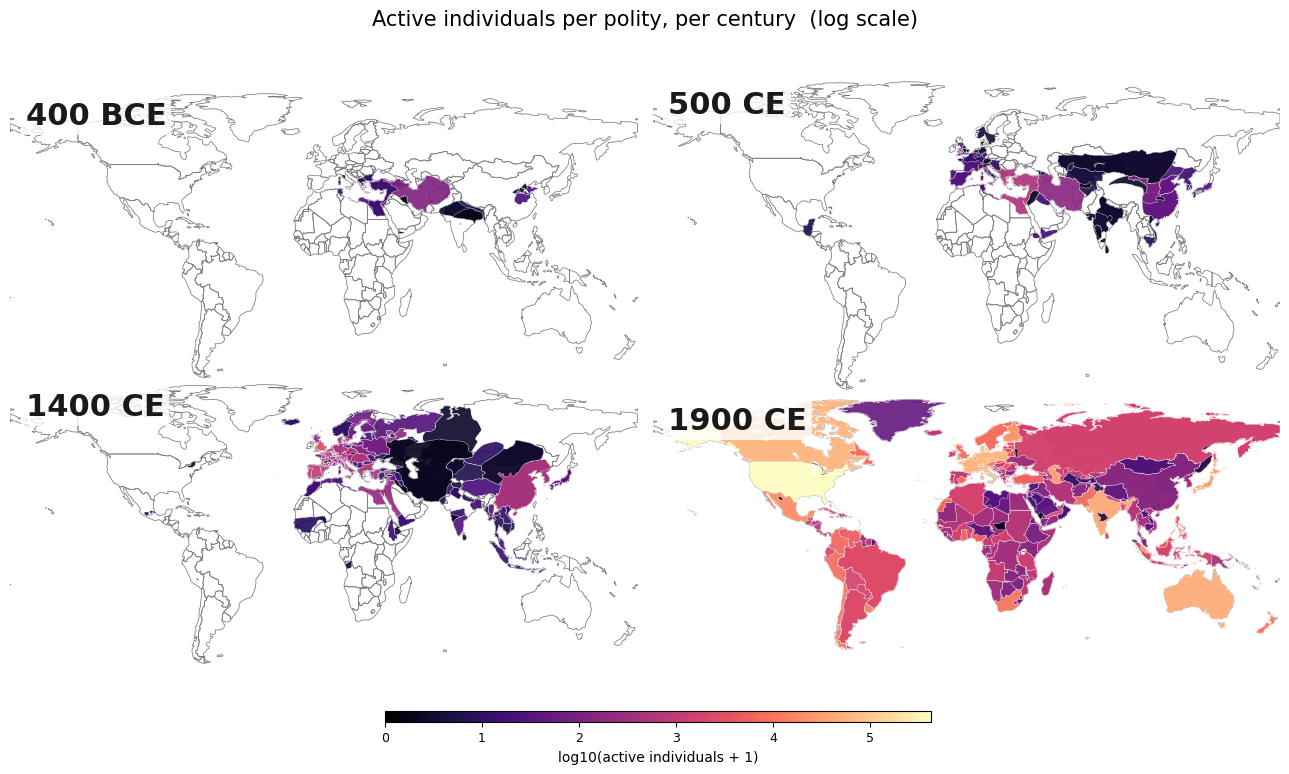

Saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/polity_century_maps/active_individuals_per_polity_2x3.png


In [6]:
render(
    all_counts,
    title='Active individuals per polity, per century  (log scale)',
    out_path=OUT_DIR / 'active_individuals_per_polity_2x3.png',
)

### Scientists

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_81131/3597926020.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.97])


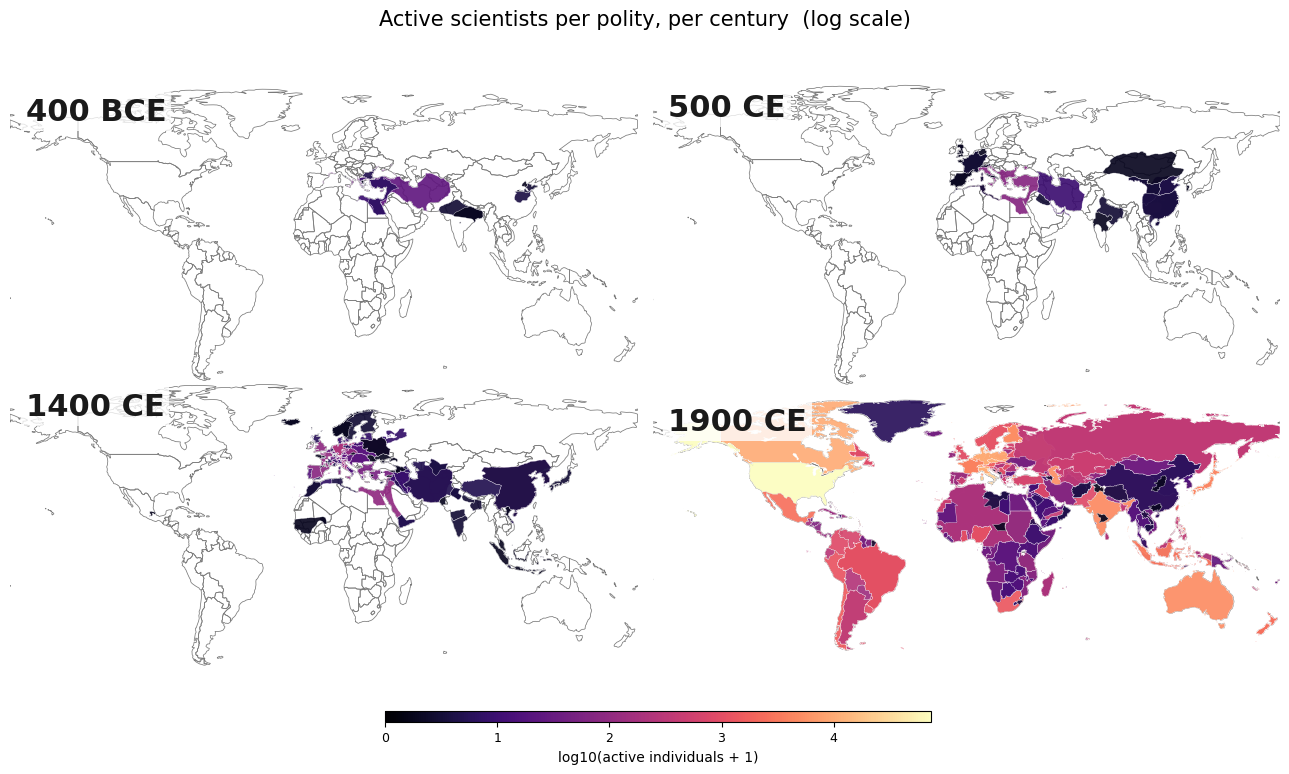

Saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/polity_century_maps/active_scientists_per_polity_2x3.png


In [7]:
render(
    sci_counts,
    title='Active scientists per polity, per century  (log scale)',
    out_path=OUT_DIR / 'active_scientists_per_polity_2x3.png',
)